<a href="https://colab.research.google.com/github/TanayBag19/nlp-ecommerce-review-sentiment-analysis/blob/main/FinalYear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string

In [ ]:
df = pd.read_csv('/content/final_dataset_with_sentiment no1.csv')

In [ ]:
df.head(20)

,Product_name,Review,Rating,Manual Sentiment
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,1
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,1
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,1
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,1
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,1
5,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Amazing laptop, am so much happy, thanks for F...",5,1
6,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,Over all a good laptop for personal use,5,1
7,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,Thank you so much Flipkart,4,1
8,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,Amazing product,5,1
9,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Good for normal work , students, online classe...",3,0


In [ ]:
df['Review'].values[0]

'Best under 60k Great performanceI got it for around 58500Battery backup is bit low but thanks to rapid charger its very fast Display is Ok for this price range Decent speakers with many customisation optionsVantage software is so good for customisationOverall good performance till nowWill update later if any problem occurs'

In [ ]:
# ── 2. QUICK LOOK ─────────────────────────────────────────────
print(df.shape)

(5086, 4)


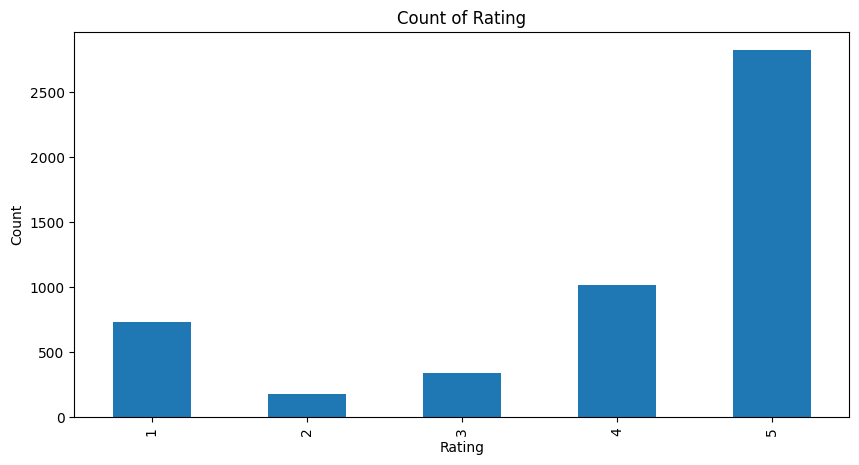

In [ ]:
# ── 3. QUICK EDA - Rating Distribution ───────────────────────
rat = df['Rating'].value_counts().sort_index().plot(
    kind='bar', title='Count of Rating', figsize=(10, 5)
)
rat.set_xlabel('Rating')
rat.set_ylabel('Count')
plt.show()

In [ ]:
# ── 4. SAMPLE REVIEW ──────────────────────────────────────────
example = df['Review'][50]
print(example)

Read this if you're going to buy any laptopMy advice is please not to look brand in buying laptops .The laptops with same specs of brands hp,full,aver,lenovo,asus etc are same To get to for minimum cost try asusDont feel asus is not as good as hp or dellFor this laptopPros- ●high speed boot up(faster than mac pro)● intel i3 good performance if your use is home,student,and coding●extra slot for ram.if you add 8 gb ram(you can get for just 2500 in flipkart and can add it yourself)You ...


In [ ]:
# ── 5. NLTK DOWNLOADS ─────────────────────────────────────────
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
# ── 6. TOKENIZE EXAMPLE ───────────────────────────────────────
tokens = nltk.word_tokenize(example)
print(tokens[:10])

['Read', 'this', 'if', 'you', "'re", 'going', 'to', 'buy', 'any', 'laptopMy']


In [ ]:
# ── 7. VADER SETUP ────────────────────────────────────────────
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
from tqdm.notebook import tqdm

sa = SentimentIntensityAnalyzer()

# Test on example
print(sa.polarity_scores(example))

{'neg': 0.053, 'neu': 0.922, 'pos': 0.025, 'compound': -0.3637}


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
# ── 8. RUN VADER ON FULL DATASET ──────────────────────────────
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Review']
    # Handle NaN values by converting them to an empty string
    if pd.isna(text):
        text = ''
    myid = i
    res[myid] = sa.polarity_scores(text)

vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'row_id'})
vaders = vaders.merge(df, left_on='row_id', right_index=True, how='left')
print(vaders)

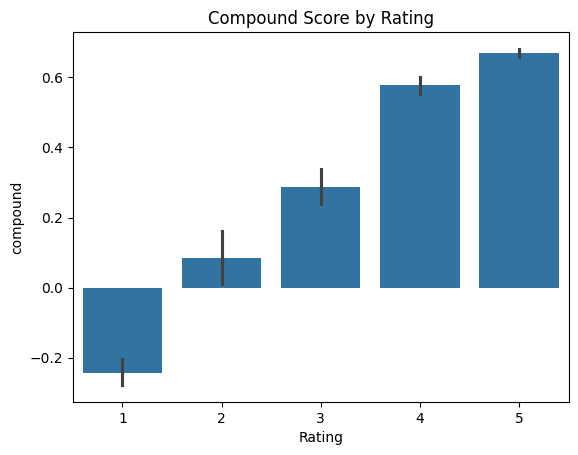

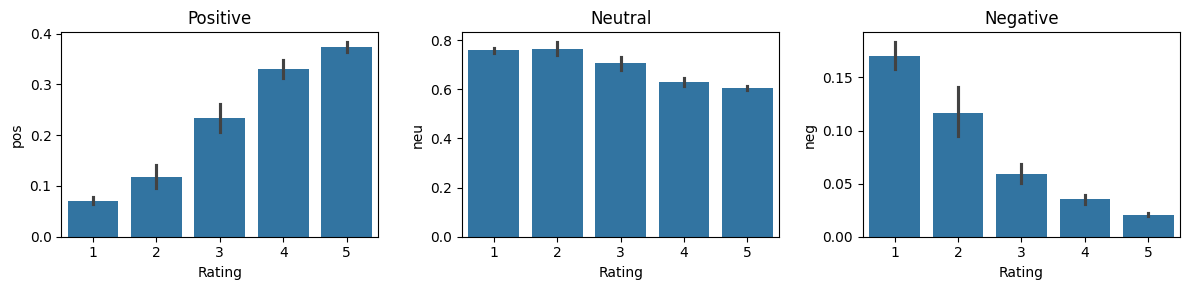

In [ ]:
# ── 9. VADER PLOTS ────────────────────────────────────────────
# Convert Rating to numeric for plotting
vaders['Rating'] = pd.to_numeric(vaders['Rating'], errors='coerce')

ax = sns.barplot(data=vaders, x='Rating', y='compound')
ax.set_title('Compound Score by Rating')
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='Rating', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Rating', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Rating', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

In [ ]:
# ── 10. RoBERTa SETUP ─────────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from scipy.special import softmax

model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
roberta_model = AutoModelForSequenceClassification.from_pretrained(model_name)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ── 11. VADER RESULT ON EXAMPLE ───────────────────────────────
print(example)
print(sa.polarity_scores(example))

Read this if you're going to buy any laptopMy advice is please not to look brand in buying laptops .The laptops with same specs of brands hp,full,aver,lenovo,asus etc are same To get to for minimum cost try asusDont feel asus is not as good as hp or dellFor this laptopPros- ●high speed boot up(faster than mac pro)● intel i3 good performance if your use is home,student,and coding●extra slot for ram.if you add 8 gb ram(you can get for just 2500 in flipkart and can add it yourself)You ...
{'neg': 0.053, 'neu': 0.922, 'pos': 0.025, 'compound': -0.3637}


In [ ]:
# ── 12. RoBERTa ON EXAMPLE ────────────────────────────────────
encoded_txt = tokenizer(example, return_tensors='pt', truncation=True, max_length=512)
output = roberta_model(**encoded_txt)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg': scores[0],
    'roberta_neu': scores[1],
    'roberta_pos': scores[2]
}
print(scores_dict)

{'roberta_neg': np.float32(0.12891823), 'roberta_neu': np.float32(0.46794757), 'roberta_pos': np.float32(0.40313423)}


In [ ]:
# ── 13. RoBERTa FUNCTION ──────────────────────────────────────
def polarity_scores_roberta(text):
    encoded_txt = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    output = roberta_model(**encoded_txt)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    return {
        'roberta_neg': scores[0],
        'roberta_neu': scores[1],
        'roberta_pos': scores[2]
    }

In [ ]:
# ── 14. RUN BOTH MODELS ON FULL DATASET ───────────────────────
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Review']
    myid = i
    # Handle NaN values by converting them to an empty string for VADER and RoBERTa
    if pd.isna(text):
        text = ''

    vader_result = sa.polarity_scores(text)
    roberta_result = polarity_scores_roberta(text)

    vader_result_rename = {f"vader_{k}": v for k, v in vader_result.items()}
    both = {**vader_result_rename, **roberta_result}
    res[myid] = both

print(roberta_result)

res_def = pd.DataFrame(res).T
res_def = res_def.reset_index().rename(columns={'index': 'row_id'})
res_def = res_def.merge(df, left_on='row_id', right_index=True, how='left')
print(res_def.head())

  0%|          | 0/5086 [00:00<?, ?it/s]

{'roberta_neg': np.float32(0.0023808293), 'roberta_neu': np.float32(0.06185053), 'roberta_pos': np.float32(0.9357686)}
   row_id  vader_neg  vader_neu  vader_pos  vader_compound  roberta_neg  \
0       0      0.073      0.613      0.314          0.9579     0.005346   
1       1      0.000      0.256      0.744          0.4404     0.005259   
2       2      0.000      0.881      0.119          0.5789     0.077736   
3       3      0.000      0.432      0.568          0.8808     0.001227   
4       4      0.000      0.533      0.467          0.8360     0.001508   

   roberta_neu  roberta_pos  \
0     0.041061     0.953593   
1     0.135149     0.859592   
2     0.282266     0.639997   
3     0.006407     0.992366   
4     0.010719     0.987773   

                                        Product_name  \
0  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
1  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
2  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
3  DELL Inspiron At

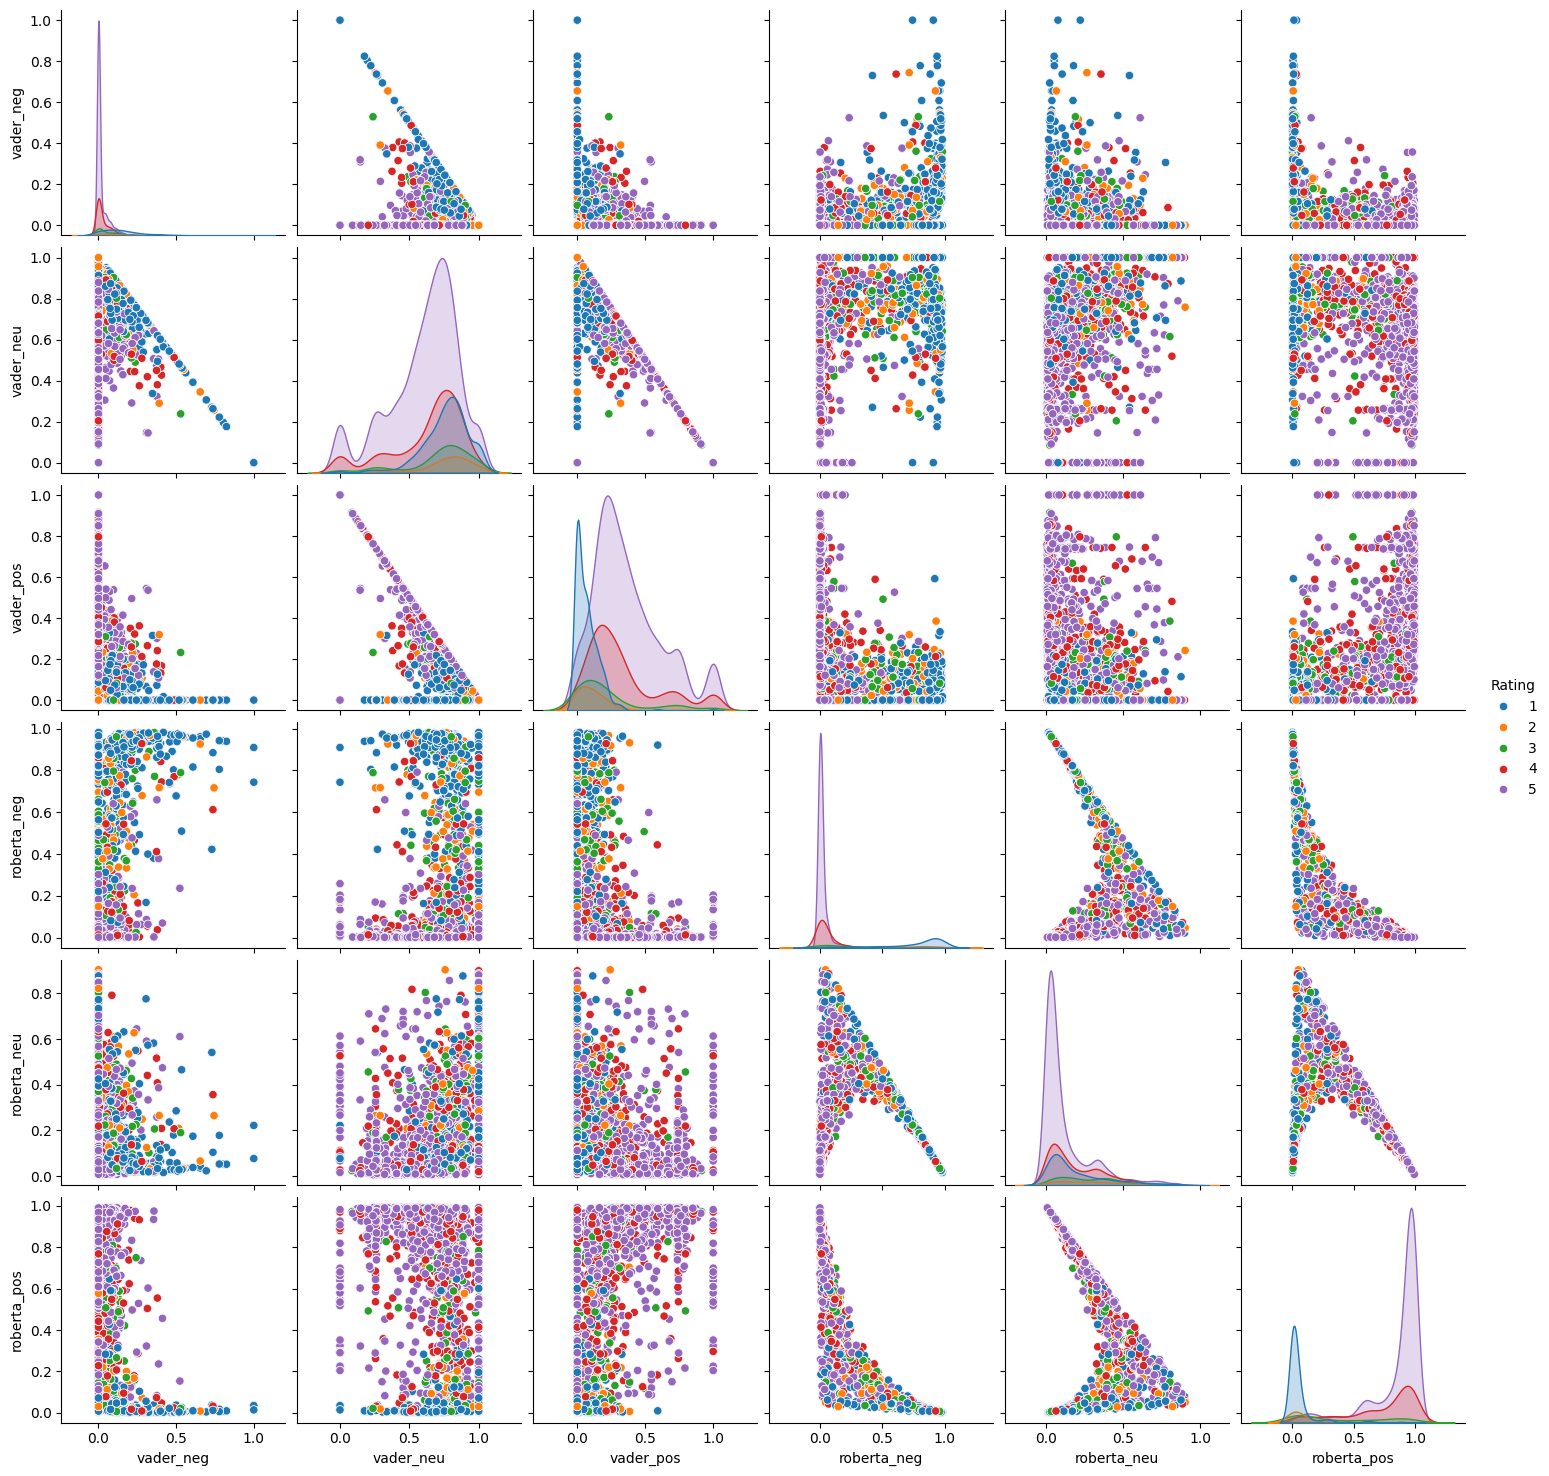

In [ ]:
# ── 15. PAIRPLOT COMPARISON ───────────────────────────────────
res_def['Rating'] = pd.to_numeric(res_def['Rating'], errors='coerce')
res_def.dropna(subset=['Rating'], inplace=True)

sns.pairplot(
    data=res_def,
    vars=['vader_neg', 'vader_neu', 'vader_pos', 'roberta_neg', 'roberta_neu', 'roberta_pos'],
    hue='Rating',
    palette='tab10'
)
plt.show()

In [ ]:
# ── 16. SAMPLE POSITIVE REVIEWS ───────────────────────────────
print(res_def.query('vader_compound > 0') \
    .sort_values('vader_pos', ascending=False)['Review'].values[0])

print(res_def.query('roberta_neu > 0') \
    .sort_values('roberta_pos', ascending=False)['Review'].values[0])

Good
That's really amazing mobile 📲...Realme 8 5G..it colour is beautiful ❤️.I love it colour....and I am so happy 😊.Thanks you flipkart.. value for money 💰.


In [ ]:
# ── 17. ACCURACY CALCULATION ──────────────────────────────────
from sklearn.metrics import accuracy_score

def rating_to_sentiment(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

res_def['actual_sentiment'] = res_def['Rating'].apply(rating_to_sentiment)
# RoBERTa predicted
def get_predicted_sentiment(row):
    scores = {
        'negative': row['roberta_neg'],
        'neutral':  row['roberta_neu'],
        'positive': row['roberta_pos']
    }
    return max(scores, key=scores.get)

res_def['roberta_predicted'] = res_def.apply(get_predicted_sentiment, axis=1)

# VADER predicted
def get_vader_pred(row):
    if row['vader_compound'] >= 0.05:
        return "positive"
    elif row['vader_compound'] <= -0.05:
        return "negative"
    else:
        return "neutral"

res_def['vader_predicted'] = res_def.apply(get_vader_pred, axis=1)

# Accuracy
roberta_acc = accuracy_score(res_def['actual_sentiment'], res_def['roberta_predicted'])
vader_acc   = accuracy_score(res_def['actual_sentiment'], res_def['vader_predicted'])

print(f"RoBERTa Sentiment Accuracy: {roberta_acc:.2f}")
print(f"VADER Sentiment Accuracy:   {vader_acc:.2f}")


RoBERTa Sentiment Accuracy: 0.83
VADER Sentiment Accuracy:   0.80


# Task
Analyze the distribution of 'Manual Sentiment' from the `df` DataFrame by converting numerical sentiment values (-1, 0, 1) to categorical labels ('negative', 'neutral', 'positive') in a new column called 'actual_manual_sentiment', treating any other values as 'unknown', and then report the value counts and identify if any 'unknown' sentiments are present.

## Analyze Manual Sentiment Distribution

### Subtask:
Convert numerical 'Manual Sentiment' values into categorical labels in a new column 'actual_manual_sentiment', handling unknown values, and then report the distribution.


**Reasoning**:
First, I will define a function to map the numerical 'Manual Sentiment' values to categorical labels. This function will convert -1 to 'negative', 0 to 'neutral', 1 to 'positive', and any other value to 'unknown'.



In [ ]:
def map_manual_sentiment(sentiment):
    if sentiment == -1:
        return 'negative'
    elif sentiment == 0:
        return 'neutral'
    elif sentiment == 1:
        return 'positive'
    else:
        return 'unknown'

print("Function `map_manual_sentiment` defined.")

Function `map_manual_sentiment` defined.


**Reasoning**:
Now that the mapping function is defined, I will apply it to the 'Manual Sentiment' column of the `df` DataFrame to create the 'actual_manual_sentiment' column. Then, I will print its value counts to check the distribution and identify any 'unknown' sentiments.



In [ ]:
df['actual_manual_sentiment'] = df['Manual Sentiment'].apply(map_manual_sentiment)
sentiment_distribution = df['actual_manual_sentiment'].value_counts()

print("Distribution of 'actual_manual_sentiment':")
print(sentiment_distribution)

if 'unknown' in sentiment_distribution.index:
    print(f"\n'Unknown' sentiment detected: {sentiment_distribution['unknown']} entries")
else:
    print("\nNo 'unknown' sentiment detected.")

Distribution of 'actual_manual_sentiment':
actual_manual_sentiment
positive    3939
negative     928
neutral      219
Name: count, dtype: int64

No 'unknown' sentiment detected.
